# SignalGuard: Time Series Anomaly Detection

## Problem Statement
Detect anomalies in industrial sensor data (temperature, vibration, pressure, etc.) to identify potential equipment failures and reduce downtime.

## Objective
- Understand sensor data patterns
- Identify anomalies visually
- Prepare data for ML models

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [6]:
import os

print(os.listdir("C:/Ml project/Time_series_Anomaly_Detection/data/raw"))
df = pd.read_csv("C:/Ml project/Time_series_Anomaly_Detection/data/raw/sensor_dataset.csv")
df.head()

['sensor_dataset.csv']


,timestamp,temperature,vibration,pressure,rotation_speed,power_consumption,anomaly
0,2026-02-24 11:14:25.091904,83.32,5.18,118.47,1460.0,59.89,0
1,2026-02-24 11:15:25.091904,82.92,6.87,101.81,1541.0,53.48,0
2,2026-02-24 11:16:25.091904,89.40,7.77,117.47,1434.7,48.99,0
3,2026-02-24 11:17:25.091904,88.65,4.78,112.68,1421.3,54.37,0
4,2026-02-24 11:18:25.091904,81.74,6.57,135.94,1503.1,57.21,0


In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 43200 entries, 0 to 43199
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          43200 non-null  str    
 1   temperature        43200 non-null  float64
 2   vibration          43200 non-null  float64
 3   pressure           43200 non-null  float64
 4   rotation_speed     43200 non-null  float64
 5   power_consumption  43200 non-null  float64
 6   anomaly            43200 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 2.3 MB


,temperature,vibration,pressure,rotation_speed,power_consumption,anomaly
count,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000
mean,80.568272,5.181671,119.278606,1495.788398,50.373836,0.033773
std,7.329909,2.058189,11.994495,63.977966,6.704641,0.180647
min,52.370000,-1.500000,26.020000,982.600000,22.900000,0.000000
25%,76.110000,4.017500,112.880000,1463.800000,46.530000,0.000000
50%,80.140000,5.050000,119.840000,1499.000000,50.060000,0.000000
75%,84.250000,6.110000,126.630000,1533.800000,53.620000,0.000000
max,141.700000,26.710000,164.940000,1847.300000,116.290000,1.000000


In [8]:
df.isnull().sum()

timestamp            0
temperature          0
vibration            0
pressure             0
rotation_speed       0
power_consumption    0
anomaly              0
dtype: int64

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by='timestamp')

In [11]:
import os

print(os.listdir("outputs"))

['metrics', 'models', 'plots']


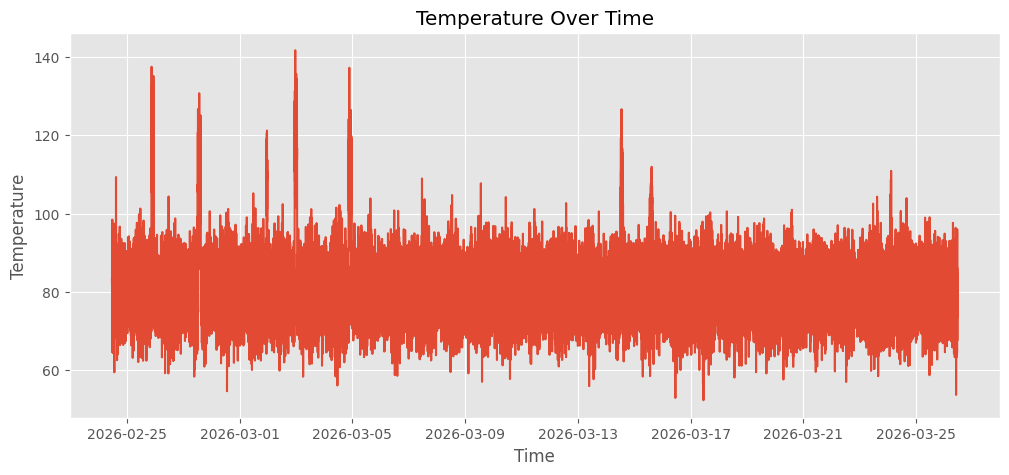

In [12]:
import os
os.makedirs("outputs/plots", exist_ok=True)

plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['temperature'])
plt.title("Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.savefig("outputs/plots/temperature_plot.png")

plt.show()

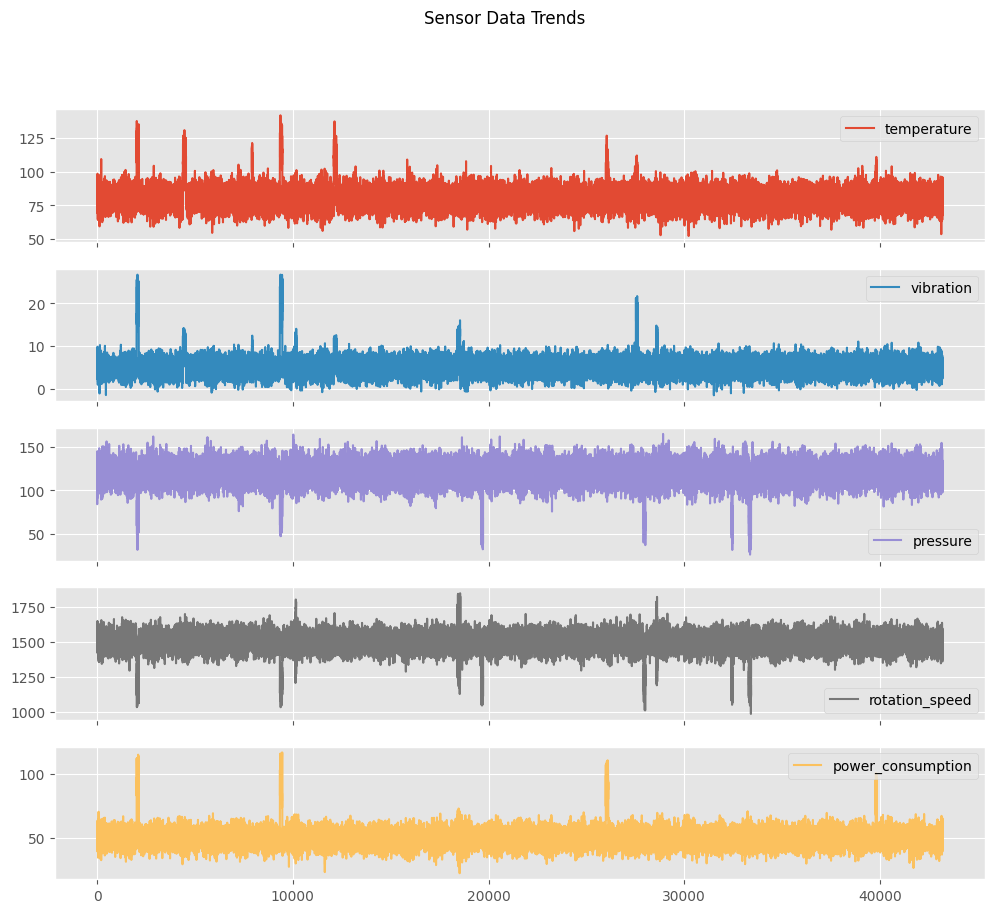

In [13]:
features = [
    'temperature',
    'vibration',
    'pressure',
    'rotation_speed',
    'power_consumption'
]

df[features].plot(subplots=True, figsize=(12,10), title="Sensor Data Trends")

import os
os.makedirs("outputs/plots", exist_ok=True)

plt.savefig("outputs/plots/sensor_data_trends.png")
plt.show()

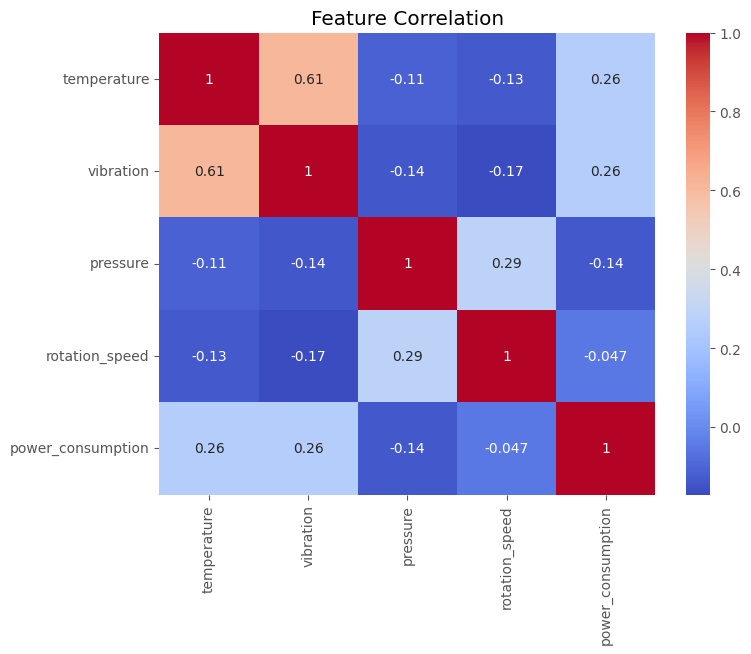

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.savefig("outputs/plots/correlation_heatmap.png", dpi=300)

plt.show()

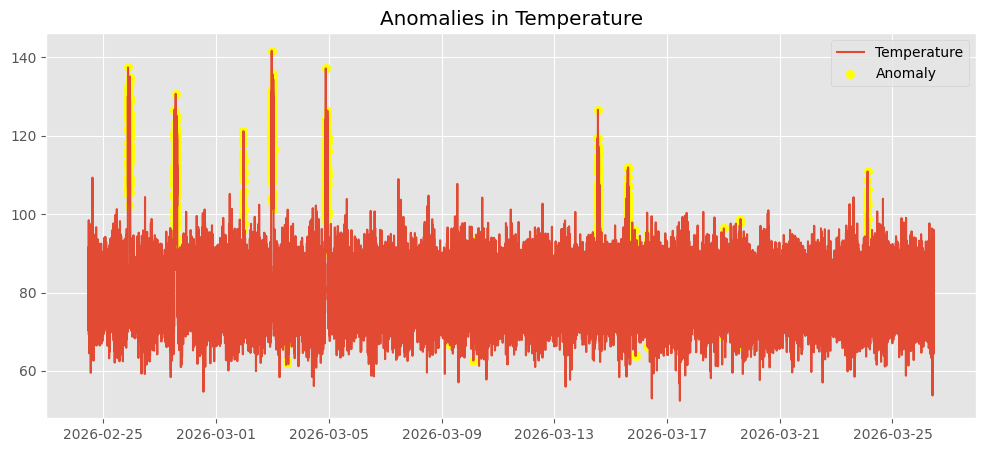

In [16]:
anomalies = df[df['anomaly'] == 1]
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['temperature'], label='Temperature')
plt.scatter(anomalies['timestamp'], anomalies['temperature'], 
            color='yellow', label='Anomaly')
plt.legend()
plt.title("Anomalies in Temperature")
plt.savefig("outputs/plots/anomaly_temperature.png", dpi=300)
plt.show()

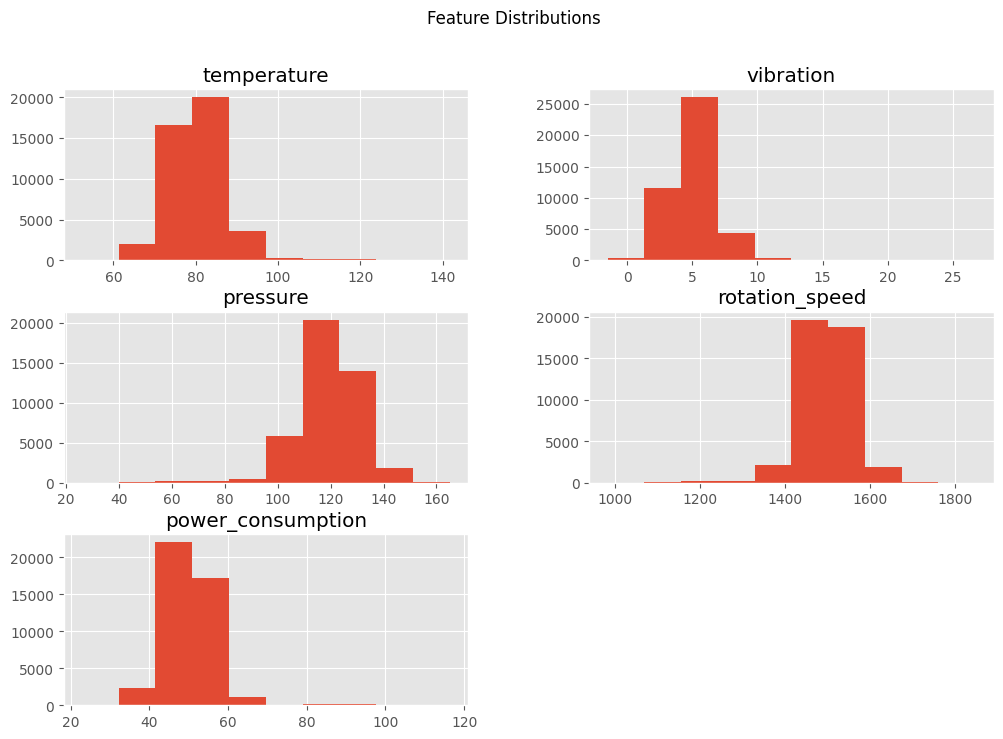

In [17]:
df[features].hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.savefig("outputs/plots/feature_distributions.png", dpi=300)
plt.show()

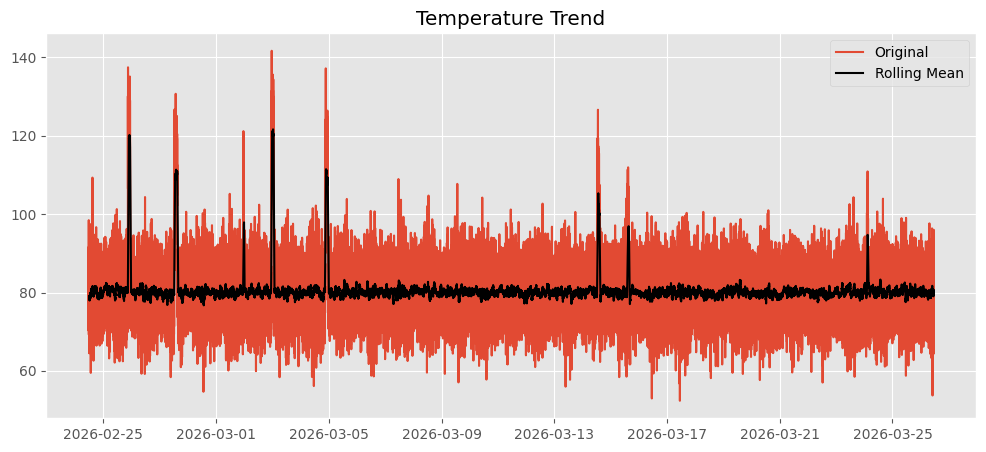

In [18]:
df['temp_rolling_mean'] = df['temperature'].rolling(window=50).mean()
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['temperature'], label='Original')
plt.plot(df['timestamp'], df['temp_rolling_mean'], 
         label='Rolling Mean', color='black')
plt.legend()
plt.title("Temperature Trend")
plt.savefig("outputs/plots/temperature_trend.png", dpi=300)
plt.show()

In [ ]:
##Key Insights
- Sensor data exhibits clear temporal patterns, indicating consistent operational behavior over time with occasional deviations.
- Anomaly events are associated with sudden spikes in key sensors such as temperature and vibration, suggesting potential mechanical stress or faults.
- Strong correlations between certain features (e.g., temperature and power consumption) indicate interdependent system behavior, which is crucial for multivariate anomaly detection.
- Anomalies are relatively rare but distinct, making them suitable for both statistical and machine learning-based detection approaches.
- Rolling trend analysis reveals gradual shifts and underlying patterns, helping identify both abrupt and progressive anomalies.